FIAP - Machine Learning & Modeling
Aula: Classificação com K-Nearest Neighbors (K-NN)

Projeto: Previsão de fidelidade de clientes de varejo em São Paulo

Objetivos de aprendizado:
- Entender a ideia básica do K-NN para classificação.
- Preparar dados (features, alvo, treino/teste).
- Aplicar K-NN com scikit-learn e avaliar o modelo.
- Visualizar a fronteira de decisão em 2D.
- Explorar o efeito do hiperparâmetro K e da normalização.

Contexto:
Você é analista de dados em uma rede de lojas de varejo em São Paulo.
Queremos prever se um cliente tende a ser 'Fiel' (1) ou 'Ocasional' (0),
com base em idade, renda, gasto médio e canal preferido.


IMPORTANTE (PARA O ENTEN DIMENTO GERAL) : ASSISTIR AO VÍDEO https://www.youtube.com/shorts/VYeaFNgQ5lc

PASSO 1 – Imports e setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 6)

PASSO 2 – Criação dos dados E salvamento em CSV

In [3]:
# ============================================
# Geração de dados sintéticos de clientes de varejo em SP
# e salvamento em arquivo CSV
# ============================================

np.random.seed(42)
n_clientes = 350

# Idade: 18 a 70 anos
idades = np.random.randint(18, 70, n_clientes)

# Renda mensal: 1500 a 20000 (com concentração em renda média)
renda = np.random.normal(loc=6000, scale=2500, size=n_clientes)
renda = np.clip(renda, 1500, 20000)

# Gasto médio mensal na rede (R$): 50 a 3000
gasto_mensal = np.random.gamma(shape=2.0, scale=200, size=n_clientes)
gasto_mensal = np.clip(gasto_mensal, 50, 3000)

# Canal preferido: 0 = loja física, 1 = online
canal_preferido = np.random.choice([0, 1], size=n_clientes, p=[0.6, 0.4])

# "Regra escondida" para fidelidade:
# - Gasto alto aumenta chance de ser fiel
# - Loja física (0) tende a gerar mais fidelidade (relacionamento)
# - Idades próximas de 35 ganham leve vantagem (perfil "família")
score = (
    (gasto_mensal / 200) * 0.7 +
    (20_000 - renda) / 20_000 * 0.2 +
    (1 - canal_preferido) * 0.5 +
    (40 - np.abs(idades - 35)) * 0.05
)

# Top ~40% do score são marcados como "fiéis"
limite = np.percentile(score, 60)
fiel = (score > limite).astype(int)  # 1 = fiel, 0 = ocasional

df = pd.DataFrame({
    "idade": idades,
    "renda_mensal": renda,
    "gasto_mensal": gasto_mensal,
    "canal_preferido": canal_preferido,  # 0 = loja física, 1 = online
    "fiel": fiel
})

csv_name = "clientes_varejo_sp.csv"
df.to_csv(csv_name, index=False)

print(f"Arquivo '{csv_name}' salvo com sucesso na pasta:")
print(os.getcwd())
df.head()

Arquivo 'clientes_varejo_sp.csv' salvo com sucesso na pasta:
/content


,idade,renda_mensal,gasto_mensal,canal_preferido,fiel
0,56,3776.213926,61.394177,0,0
1,69,3960.474288,494.231479,0,0
2,46,5807.245726,172.547024,0,0
3,32,6852.879937,50.752477,0,0
4,60,6691.726998,404.990971,0,0


PASSO 3 – Carregando os dados a partir do CSV

In [4]:
# ============================================
# Carregando o dataset de clientes de varejo a partir do CSV
# ============================================

df = pd.read_csv("clientes_varejo_sp.csv")
print("Dimensões do dataset:", df.shape)
df.head()

Dimensões do dataset: (350, 5)


,idade,renda_mensal,gasto_mensal,canal_preferido,fiel
0,56,3776.213926,61.394177,0,0
1,69,3960.474288,494.231479,0,0
2,46,5807.245726,172.547024,0,0
3,32,6852.879937,50.752477,0,0
4,60,6691.726998,404.990971,0,0


PASSO 4 – Análise descritiva rápida (EDA)

In [5]:
df.describe()

,idade,renda_mensal,gasto_mensal,canal_preferido,fiel
count,350.000000,350.000000,350.000000,350.000000,350.000000
mean,43.391429,6088.979669,423.067394,0.397143,0.400000
std,15.190611,2427.016273,283.460146,0.490007,0.490599
min,18.000000,1500.000000,50.000000,0.000000,0.000000
25%,31.000000,4235.791309,214.499022,0.000000,0.000000
50%,43.000000,6042.507167,363.044738,0.000000,0.000000
75%,56.000000,7648.614547,551.896237,1.000000,1.000000
max,69.000000,15631.828727,1537.029195,1.000000,1.000000


/tmp/ipykernel_3044/2547354742.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["Loja Física (0)", "Online (1)"])


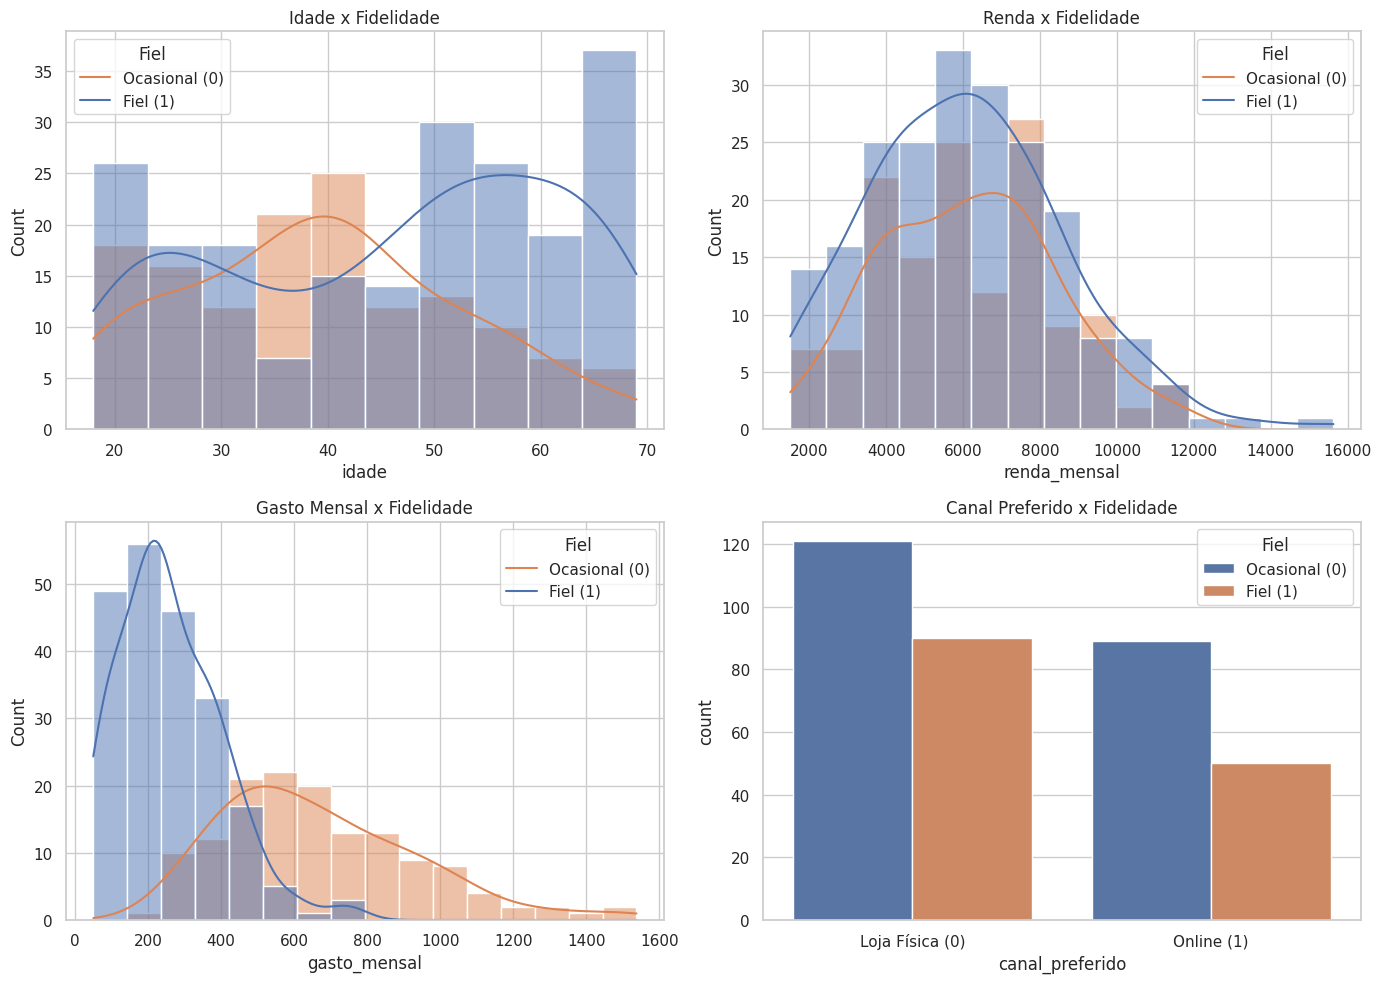

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x="idade", hue="fiel", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Idade x Fidelidade")
axes[0, 0].legend(title="Fiel", labels=["Ocasional (0)", "Fiel (1)"])

sns.histplot(data=df, x="renda_mensal", hue="fiel", kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Renda x Fidelidade")
axes[0, 1].legend(title="Fiel", labels=["Ocasional (0)", "Fiel (1)"])

sns.histplot(data=df, x="gasto_mensal", hue="fiel", kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Gasto Mensal x Fidelidade")
axes[1, 0].legend(title="Fiel", labels=["Ocasional (0)", "Fiel (1)"])

sns.countplot(data=df, x="canal_preferido", hue="fiel", ax=axes[1, 1])
axes[1, 1].set_xticklabels(["Loja Física (0)", "Online (1)"])
axes[1, 1].set_title("Canal Preferido x Fidelidade")
axes[1, 1].legend(title="Fiel", labels=["Ocasional (0)", "Fiel (1)"])

plt.tight_layout()
plt.show()

PASSO 5 – Separando features (X) e alvo (y)

In [7]:
# Features (X) e alvo (y)
X = df[["idade", "renda_mensal", "gasto_mensal", "canal_preferido"]]
y = df["fiel"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (350, 4)
Formato de y: (350,)


PASSO 6 – Dividindo em treino e teste

In [8]:
# 70% treino, 30% teste, estratificado pela classe (fiel/ocasional)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamanho treino:", X_train.shape[0])
print("Tamanho teste:", X_test.shape[0])

Tamanho treino: 245
Tamanho teste: 105


PASSO 7 – Normalização (StandardScaler)

In [9]:
# Normalização é crucial para K-NN (distâncias)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Primeiras linhas ANTES da escala:")
print(X_train.head())

print("\nPrimeiras linhas DEPOIS da escala (array):")
print(X_train_scaled[:5])

Primeiras linhas ANTES da escala:
     idade  renda_mensal  gasto_mensal  canal_preferido
180     62   6777.268914    477.336142                1
217     66  10690.427098    529.316404                0
292     69   4250.686230    927.271332                1
274     57   2738.826249    192.643231                1
152     32   3954.448292    323.224189                1

Primeiras linhas DEPOIS da escala (array):
[[ 1.29614557  0.27461744  0.17877911  1.26743165]
 [ 1.55686451  1.88969406  0.35628628 -0.78899718]
 [ 1.75240371 -0.76817828  1.71526086  1.26743165]
 [ 0.9702469  -1.39216781 -0.7934175   1.26743165]
 [-0.65924645 -0.89044448 -0.34749714  1.26743165]]


PASSO 8 – Primeiro modelo K-NN (K=5)

In [10]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia no teste com K={k}: {acc:.3f}")
print("\nRelatório de classificação:")
print(classification_report(
    y_test, y_pred,
    target_names=["Ocasional (0)", "Fiel (1)"]
))

Acurácia no teste com K=5: 0.886

Relatório de classificação:
               precision    recall  f1-score   support

Ocasional (0)       0.90      0.90      0.90        63
     Fiel (1)       0.86      0.86      0.86        42

     accuracy                           0.89       105
    macro avg       0.88      0.88      0.88       105
 weighted avg       0.89      0.89      0.89       105



PASSO 9 – Matriz de confusão

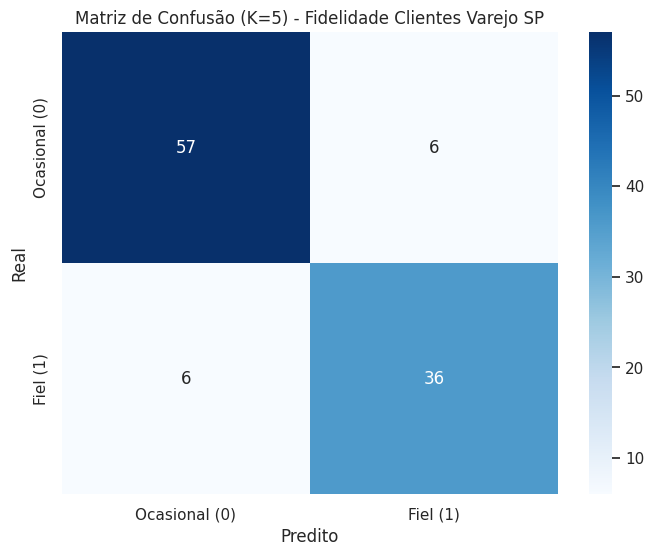

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Ocasional (0)", "Fiel (1)"],
    yticklabels=["Ocasional (0)", "Fiel (1)"]
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(f"Matriz de Confusão (K={k}) - Fidelidade Clientes Varejo SP")
plt.show()

PASSO 10 – Desafio 1: Acurácia x K

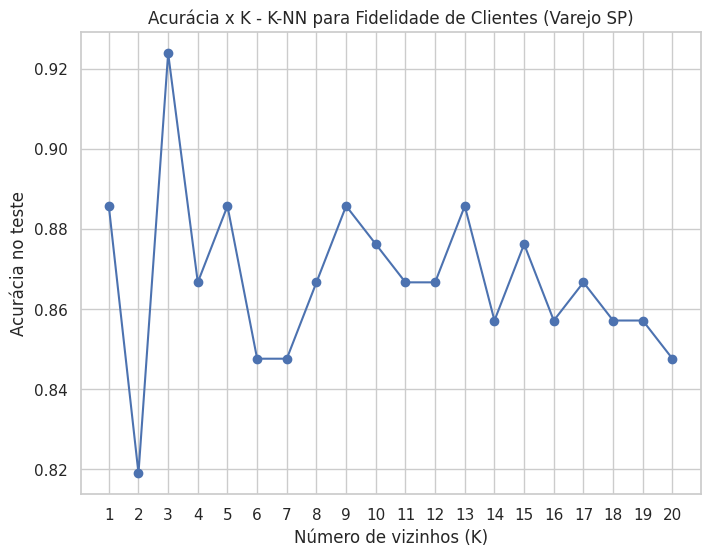

Melhor K (pelo gráfico/array) está próximo de: 3


In [12]:
# Desafio 1:
# - Testar vários valores de K (1 a 20)
# - Plotar a acurácia em função de K
# - Observar qual K parece melhor

k_values = range(1, 21)
accuracies = []

for k_val in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k_val)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc_temp = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc_temp)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Número de vizinhos (K)")
plt.ylabel("Acurácia no teste")
plt.title("Acurácia x K - K-NN para Fidelidade de Clientes (Varejo SP)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[int(np.argmax(accuracies))]
print("Melhor K (pelo gráfico/array) está próximo de:", best_k)

PASSO 11 – Visualização 2D (idade x gasto_mensal)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


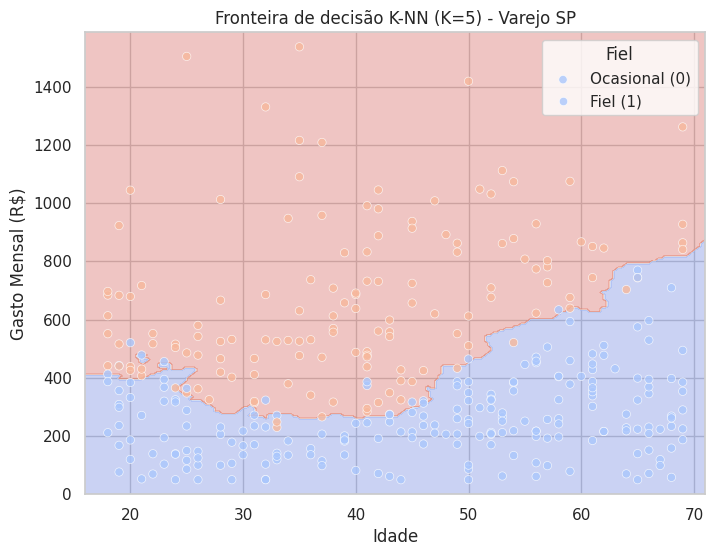

In [13]:
# Para visualização 2D da fronteira de decisão, vamos usar só:
# idade e gasto_mensal

X_2d = df[["idade", "gasto_mensal"]]
y_2d = df["fiel"]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d,
    test_size=0.3,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

k_vis = 5
knn_2d = KNeighborsClassifier(n_neighbors=k_vis)
knn_2d.fit(X_train_2d_scaled, y_train_2d)

# Grid para desenhar a fronteira
x_min, x_max = X_2d["idade"].min() - 2, X_2d["idade"].max() + 2
y_min, y_max = X_2d["gasto_mensal"].min() - 50, X_2d["gasto_mensal"].max() + 50

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points_scaled = scaler_2d.transform(grid_points)
Z = knn_2d.predict(grid_points_scaled)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
sns.scatterplot(
    x=X_2d["idade"], y=X_2d["gasto_mensal"],
    hue=y_2d, palette="coolwarm", alpha=0.8
)
plt.xlabel("Idade")
plt.ylabel("Gasto Mensal (R$)")
plt.title(f"Fronteira de decisão K-NN (K={k_vis}) - Varejo SP")
plt.legend(title="Fiel", labels=["Ocasional (0)", "Fiel (1)"])
plt.show()

PASSO 12 – Desafio 2: variar K na visualização 2D

In [14]:
# Desafio 2:
# - Altere o valor de k_vis (por exemplo, 1, 3, 10, 15, 20)
# - Rode novamente a célula de visualização (Célula 12)
# - Observe como a fronteira de decisão muda
#
# Questões:
# - Com K muito pequeno (K=1), a fronteira fica "recortada"? Isso lembra overfitting?
# - Com K muito grande, o modelo fica "bonzinho demais", ignorando detalhes?
#
# Teste e discuta em grupo.

PASSO 13 – Desafio 3: weights="distance"

In [15]:
# Desafio 3:
# - Comparar weights='uniform' vs weights='distance'

knn_uniform = KNeighborsClassifier(n_neighbors=5, weights="uniform")
knn_uniform.fit(X_train_scaled, y_train)
acc_uniform = accuracy_score(y_test, knn_uniform.predict(X_test_scaled))

knn_distance = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn_distance.fit(X_train_scaled, y_train)
acc_distance = accuracy_score(y_test, knn_distance.predict(X_test_scaled))

print(f"Acurácia com weights='uniform'  (K=5): {acc_uniform:.3f}")
print(f"Acurácia com weights='distance' (K=5): {acc_distance:.3f}")

# Perguntas:
# - A diferença foi grande?
# - Em quais cenários você acha que dar mais peso aos vizinhos mais próximos
#   pode fazer mais diferença?

Acurácia com weights='uniform'  (K=5): 0.886
Acurácia com weights='distance' (K=5): 0.886


PASSO 14 – Conclusões

Resumo do que fizemos hoje (Varejo SP + K-NN):
- Geramos e salvamos um dataset CSV de clientes de varejo em São Paulo.
- Carregamos o CSV e fizemos uma análise exploratória básica.
- Construímos um modelo K-NN para prever se um cliente é Fiel ou Ocasional.
- Entendemos a importância da normalização para algoritmos baseados em distância.
- Exploramos o efeito do hiperparâmetro K na acurácia e na fronteira de decisão.
- Testamos diferentes configurações (weights='uniform' vs 'distance').

Perguntas para reflexão:
1) Que outras variáveis reais de varejo você adicionaria ao modelo?
   (ex.: número de lojas visitadas, tempo de cadastro, categoria favorita, canal de marketing)
2) Como esse modelo poderia ser usado em campanhas de CRM/marketing de fidelização?
3) Em uma base muito grande (milhões de clientes), quais limitações do K-NN aparecem?
4) Qual modelo você testaria depois de K-NN como próximo passo (árvores, regressão logística, etc.)?
